# Class-Agnostic Insect Detection: SAM2 Segment-Everything

This notebook implements a high-recall pipeline for dense insect clusters (e.g., black scale) where zero-shot detectors lack specific semantic representation.

**Strategy:**
1. **SAM2 Automatic Mask Generation**: Propose every potential object using a dense point grid.
2. **Geometric & Color Filtering**: Isolate insects based on physical priors (size, ovality, and darkness relative to leaf).
3. **Robust Leaf Segmentation**: Multi-point SAM2 prompt with color-prior fallback for leaf-relative severity metrics.

In [ ]:
!pip install -q "ultralytics>=8.4.0" opencv-python-headless scipy matplotlib ensemble-boxes

## 1. Setup & Models

We initialize SAM2 for automatic proposal generation. We no longer rely on YOLOE's zero-shot text prompting for the detection phase.

In [ ]:
import numpy as np
import cv2
import torch
import matplotlib.pyplot as plt
from scipy import ndimage
from ultralytics import SAM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

sam_model = SAM("sam2_l.pt")
print("Model ready.")

Device: cuda
Models ready.


## 2. Upload image

In [ ]:
from google.colab import files
uploaded = files.upload()
IMG_PATH = list(uploaded.keys())[0]

bgr = cv2.imread(IMG_PATH)
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
H, W = bgr.shape[:2]
print(f"Loaded {IMG_PATH} — {W}x{H}")

Saving citrus_citrusblackfly_00222.jpeg to citrus_citrusblackfly_00222 (1).jpeg
Loaded citrus_citrusblackfly_00222 (1).jpeg — 548x345


## 3. Insect class prompts (text)

Short 2–4 word noun phrases, grouped into canonical classes. Multiple synonym
phrases per class act as a cheap prompt ensemble — WBF later merges the duplicate
boxes they produce on the same insect. Distractor phrases are included so common
false-positive triggers (droplets, shadows, soil) get their own competing class
instead of stealing boxes from the insect classes; they're discarded after inference.

If a run comes back with 0 detections, this list is the first thing to widen —
add phrases that describe the actual shape/color/texture you're looking at (e.g.
"shiny black beetle", "cluster of black scale insects", "dark oval bumps on leaf")
rather than assuming the object isn't there.

In [ ]:
INSECT_PROMPTS = {
    "aphid":             ["aphid", "aphids on leaf", "cluster of small green insects", "tiny bugs on stem"],
    "whitefly":          ["whitefly", "small white insects on leaf", "tiny white flies"],
    "scale_mealybug":    ["scale insects", "white cottony mass on plant", "mealybug", "waxy bumps on stem",
                           "cluster of black scale insects", "dark oval bumps on leaf"],
    "larva_caterpillar": ["caterpillar", "larva on leaf", "green worm on plant", "grub"],
    "beetle_bug":        ["beetle on leaf", "insect on leaf", "bug on plant", "shiny black beetle",
                           "cluster of black beetles"],
    "egg_mass":          ["insect eggs on leaf", "cluster of yellow eggs", "cluster of dark eggs"],
}
DISTRACTOR_PROMPTS = ["water droplet", "shadow", "soil", "leaf vein", "leaf stem", "finger", "human skin"]

PHRASE2CLASS = {p: c for c, phrases in INSECT_PROMPTS.items() for p in phrases}
DISTRACTOR_SET = set(DISTRACTOR_PROMPTS)
ALL_PROMPTS = list(PHRASE2CLASS.keys()) + DISTRACTOR_PROMPTS

yoloe_model.set_classes(ALL_PROMPTS)
print(f"{len(ALL_PROMPTS)} prompt phrases loaded "
      f"({len(INSECT_PROMPTS)} insect classes + {len(DISTRACTOR_PROMPTS)} distractors)")

32 prompt phrases loaded (6 insect classes + 7 distractors)


## 4. Tiled detection

Full-res leaf photos downsampled to a 640/1024 input erase aphid/whitefly/egg-scale
objects before the detector ever sees them. Two passes, both on the **full image**
(no leaf mask to restrict to):

- **Tiled pass** (640px tiles, 20% overlap, low conf) — recall for tiny/dense bodies.
- **Full-frame pass** — catches large single instances (caterpillar, beetle cluster)
  that tiling would otherwise cut across tile boundaries.

`conf=0.05` here is intentionally loose — recall is recovered by widening prompts and
lowering this if you get 0 detections; precision is cleaned up in the filter step below.

In [ ]:
def make_tiles(w, h, tile=640, overlap=0.2):
    step = int(tile * (1 - overlap))
    xs = list(range(0, max(w - tile, 0) + 1, step)) or [0]
    ys = list(range(0, max(h - tile, 0) + 1, step)) or [0]
    if xs[-1] + tile < w:
        xs.append(w - tile)
    if ys[-1] + tile < h:
        ys.append(h - tile)
    tiles = set()
    for y, x in product(ys, xs):
        x, y = max(0, x), max(0, y)
        x2, y2 = min(x + tile, w), min(y + tile, h)
        tiles.add((max(0, x2 - tile), max(0, y2 - tile), x2, y2))
    return sorted(tiles)


def detect_tiled(model, bgr, tile=640, overlap=0.2, conf=0.05, iou=0.5):
    h, w = bgr.shape[:2]
    tiles = make_tiles(w, h, tile, overlap)
    all_boxes, all_scores, all_names = [], [], []
    for (x1, y1, x2, y2) in tiles:
        crop = bgr[y1:y2, x1:x2]
        res = model.predict(crop, conf=conf, iou=iou, agnostic_nms=True, verbose=False)[0]
        if res.boxes is None or len(res.boxes) == 0:
            continue
        xyxy = res.boxes.xyxy.cpu().numpy()
        confs = res.boxes.conf.cpu().numpy()
        cls_ids = res.boxes.cls.cpu().numpy().astype(int)
        names = [res.names[i] for i in cls_ids]
        xyxy[:, [0, 2]] += x1
        xyxy[:, [1, 3]] += y1
        all_boxes.append(xyxy)
        all_scores.append(confs)
        all_names.extend(names)
    if not all_boxes:
        return np.zeros((0, 4)), np.zeros(0), []
    return np.concatenate(all_boxes), np.concatenate(all_scores), all_names


boxes_tiled, scores_tiled, names_tiled = detect_tiled(
    yoloe_model, bgr, tile=640, overlap=0.2, conf=0.05
)

res_full = yoloe_model.predict(bgr, conf=0.08, agnostic_nms=True, verbose=False)[0]
if res_full.boxes is not None and len(res_full.boxes) > 0:
    boxes_full = res_full.boxes.xyxy.cpu().numpy()
    scores_full = res_full.boxes.conf.cpu().numpy()
    names_full = [res_full.names[i] for i in res_full.boxes.cls.cpu().numpy().astype(int)]
else:
    boxes_full, scores_full, names_full = np.zeros((0, 4)), np.zeros(0), []

print(f"Tiled pass:      {len(boxes_tiled)} raw boxes across {len(make_tiles(W, H))} tiles")
print(f"Full-frame pass: {len(boxes_full)} raw boxes")
if len(boxes_tiled) == 0 and len(boxes_full) == 0:
    print("\n0 raw detections \u2014 before touching thresholds, widen INSECT_PROMPTS with phrases "
          "that describe this image's actual objects, then re-run from cell 3.")

Tiled pass:      6 raw boxes across 1 tiles
Full-frame pass: 3 raw boxes


## 5. Merge with Weighted Box Fusion

WBF averages overlapping boxes instead of discarding them like NMS — important here
since synonym phrases and the two passes both produce near-duplicate boxes on the
same insect.

In [ ]:
# from ensemble_boxes import weighted_boxes_fusion

# def wbf_merge(boxes_list, scores_list, names_list, w, h, iou_thr=0.5, skip_box_thr=0.03):
#     all_names = sorted(set(n for names in names_list for n in names))
#     name2id = {n: i for i, n in enumerate(all_names)}

#     norm_boxes, norm_scores, norm_labels = [], [], []
#     for boxes, scores, names in zip(boxes_list, scores_list, names_list):
#         if len(boxes) == 0:
#             norm_boxes.append([]); norm_scores.append([]); norm_labels.append([])
#             continue
#         nb = boxes.copy().astype(float)
#         nb[:, [0, 2]] /= w
#         nb[:, [1, 3]] /= h
#         nb = np.clip(nb, 0, 1)
#         norm_boxes.append(nb.tolist())
#         norm_scores.append(scores.tolist())
#         norm_labels.append([name2id[n] for n in names])

#     merged_boxes, merged_scores, merged_labels = weighted_boxes_fusion(
#         norm_boxes, norm_scores, norm_labels, iou_thr=iou_thr, skip_box_thr=skip_box_thr
#     )
#     if len(merged_boxes):
#         merged_boxes[:, [0, 2]] *= w
#         merged_boxes[:, [1, 3]] *= h
#     merged_names = [all_names[int(i)] for i in merged_labels]
#     return np.array(merged_boxes), np.array(merged_scores), merged_names


# m_boxes, m_scores, m_names = wbf_merge(
#     [boxes_tiled, boxes_full], [scores_tiled, scores_full], [names_tiled, names_full], W, H
# )
# print(f"After WBF merge: {len(m_boxes)} candidate boxes")

# Skip WBF — concatenate raw detections directly instead
m_boxes = np.concatenate([b for b in [boxes_tiled, boxes_full] if len(b)]) if (len(boxes_tiled) or len(boxes_full)) else np.zeros((0,4))
m_scores = np.concatenate([s for s in [scores_tiled, scores_full] if len(s)]) if (len(scores_tiled) or len(scores_full)) else np.zeros(0)
m_names = names_tiled + names_full

print(f"Raw candidates (no WBF): {len(m_boxes)} boxes")

Raw candidates (no WBF): 9 boxes


## 6. Filter proposals

No leaf mask to check "is this box on the leaf" against, so filtering is purely
image-level now: drop distractor-class hits, boxes that are implausibly large
relative to the *image* (not the leaf — still catches the "whole frame" failure
mode), and degenerate aspect ratios. Then map surviving phrases back to their
canonical class.

In [ ]:
def filter_detections(boxes, scores, names, img_w, img_h, max_area_frac=0.15, max_aspect=6.0):
    img_area = img_w * img_h
    keep_boxes, keep_scores, keep_classes = [], [], []
    for box, score, name in zip(boxes, scores, names):
        if name in DISTRACTOR_SET:
            continue
        canonical = PHRASE2CLASS.get(name, name)
        x1, y1, x2, y2 = [int(round(v)) for v in box]
        x1, y1 = max(0, x1), max(0, y1)
        x2, y2 = min(img_w, x2), min(img_h, y2)
        if x2 <= x1 or y2 <= y1:
            continue
        bw, bh = x2 - x1, y2 - y1
        if (bw * bh) / img_area > max_area_frac:
            continue  # implausibly large — likely a whole-frame false positive
        if max(bw, bh) / max(1, min(bw, bh)) > max_aspect:
            continue
        keep_boxes.append([x1, y1, x2, y2])
        keep_scores.append(score)
        keep_classes.append(canonical)
    return np.array(keep_boxes), np.array(keep_scores), keep_classes


f_boxes, f_scores, f_classes = filter_detections(m_boxes, m_scores, m_names, W, H)
print(f"After filtering: {len(f_boxes)} instances kept")
for c in sorted(set(f_classes)):
    print(f"  {c}: {f_classes.count(c)}")

After filtering: 4 instances kept
  aphid: 1
  beetle_bug: 1
  scale_mealybug: 2


## 7. Optional: visual-prompt pass

Text prompts carry your class name into the output. Visual prompts don't — results
come back as `object0`, `object1`, ... grouped by the class ID you assigned, so map
them back to your own names yourself (`vp_id2class` below).

This is the strongest fallback when the text pass returns 0: crop 1–2 exemplar boxes
directly from this image by eye, and YOLOE matches on visual similarity instead of a
word it may not have a good embedding for. Note: visual-prompt confidences typically
come back very low (hundredths) — rank and take top-k rather than thresholding on an
absolute value.

In [ ]:
USE_VISUAL_PROMPTS = False  # flip on and fill in real exemplar boxes to try this

if USE_VISUAL_PROMPTS:
    vp_boxes = np.array([
        [812, 430, 838, 452],  # example: crop one clean instance by eye from this image
    ])
    vp_id2class = {0: "scale_mealybug"}  # your best guess at what it is
    visual_prompts = {"bboxes": vp_boxes, "cls": np.array(list(vp_id2class.keys()))}

    # Separate model instance — visual prompting overwrites the text-prompt class state.
    vp_model = YOLOE("yoloe-26l-seg.pt")
    vp_res = vp_model.predict(
        bgr, visual_prompts=visual_prompts, predictor=YOLOEVPSegPredictor,
        conf=0.03, verbose=False,
    )[0]

    if vp_res.boxes is not None and len(vp_res.boxes) > 0:
        vp_boxes_out = vp_res.boxes.xyxy.cpu().numpy()
        vp_scores_out = vp_res.boxes.conf.cpu().numpy()
        vp_cls_out = vp_res.boxes.cls.cpu().numpy().astype(int)
        vp_names_out = [vp_id2class[i] for i in vp_cls_out]

        vf_boxes, vf_scores, vf_classes = filter_detections(
            vp_boxes_out, vp_scores_out, vp_names_out, W, H
        )
        f_boxes = np.concatenate([f_boxes, vf_boxes]) if len(f_boxes) else vf_boxes
        f_scores = np.concatenate([f_scores, vf_scores]) if len(f_scores) else vf_scores
        f_classes = f_classes + vf_classes
        print(f"Visual-prompt pass added {len(vf_boxes)} instances")

## 8. SAM2 refinement per detected instance

This is now the *only* SAM2 step. Each box YOLOE found is cropped with padding,
upscaled, segmented, then pasted back — a 15×15px box prompt on a full-res image
gives SAM2 very little to work with otherwise. If SAM2 fails on one box it just
means that one instance has no mask; it no longer affects any other instance or
the count, unlike the old leaf-mask-gated version.

In [ ]:
def refine_with_sam2(sam_model, bgr, box, pad_frac=0.6, upscale=3, min_side=40):
    H, W = bgr.shape[:2]
    x1, y1, x2, y2 = box
    bw, bh = x2 - x1, y2 - y1
    pad_x, pad_y = bw * pad_frac, bh * pad_frac
    cx1, cy1 = max(0, int(x1 - pad_x)), max(0, int(y1 - pad_y))
    cx2, cy2 = min(W, int(x2 + pad_x)), min(H, int(y2 + pad_y))
    crop = bgr[cy1:cy2, cx1:cx2]
    if crop.size == 0:
        return np.zeros((H, W), bool)

    scale = upscale if max(bw, bh) < min_side else 1
    crop_big = cv2.resize(crop, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC) if scale > 1 else crop

    box_in_crop = [(x1 - cx1) * scale, (y1 - cy1) * scale, (x2 - cx1) * scale, (y2 - cy1) * scale]
    try:
        res = sam_model.predict(crop_big, bboxes=[box_in_crop], verbose=False)
    except Exception:
        return np.zeros((H, W), bool)
    if res[0].masks is None:
        return np.zeros((H, W), bool)
    mask_small = res[0].masks.data.cpu().numpy()[0] > 0.5
    mask_crop = cv2.resize(mask_small.astype(np.uint8), (crop.shape[1], crop.shape[0]),
                            interpolation=cv2.INTER_NEAREST) > 0

    full_mask = np.zeros((H, W), bool)
    full_mask[cy1:cy2, cx1:cx2] = mask_crop
    return full_mask


instance_masks = [refine_with_sam2(sam_model, bgr, box) for box in f_boxes]
n_empty = sum(1 for m in instance_masks if not m.any())
print(f"SAM2-refined {len(instance_masks)} instance masks ({n_empty} came back empty)")

SAM2-refined 4 instance masks (0 came back empty)


## 9. Metrics

No leaf mask means no leaf-area denominator, so coverage below is reported as a
% of the **photographed frame**, not % of leaf — fine for comparing photos taken
at a consistent framing, but not directly comparable across different crop/zoom
levels the way a true leaf-relative number would be. If you need leaf-relative
severity, segment the leaf separately (see notes) and divide by that instead.

In [ ]:
PX_PER_CM = None  # e.g. measure a coin/ruler in the image and set this to get insects/cm^2

img_px = W * H
class_counts = {c: f_classes.count(c) for c in sorted(set(f_classes))}
total_insects = len(f_classes)

body_union = np.zeros((H, W), bool)
for m in instance_masks:
    body_union |= m
body_coverage_pct = 100.0 * body_union.sum() / img_px


def grade(count, coverage_pct):
    if count == 0:
        return "0 - None detected"
    if count < 10 and coverage_pct < 1:
        return "1 - Trace"
    if count < 50 and coverage_pct < 3:
        return "2 - Light infestation"
    if count < 200 and coverage_pct < 8:
        return "3 - Moderate infestation"
    return "4 - Heavy infestation"


print(f"Frame area       : {img_px:,} px")
print(f"Insects detected : {total_insects}  ({', '.join(f'{k}: {v}' for k, v in class_counts.items())})")
if PX_PER_CM:
    frame_cm2 = img_px / (PX_PER_CM ** 2)
    print(f"Density          : {total_insects / frame_cm2:.2f} insects/cm^2")
else:
    print("Density          : set PX_PER_CM (ruler/coin in frame) for insects/cm^2")
print(f"Body coverage    : {body_coverage_pct:.2f}% of frame")
print(f"Grade            : {grade(total_insects, body_coverage_pct)}")

Frame area       : 189,060 px
Insects detected : 4  (aphid: 1, beetle_bug: 1, scale_mealybug: 2)
Density          : set PX_PER_CM (ruler/coin in frame) for insects/cm^2
Body coverage    : 2.56% of frame
Grade            : 2 - Light infestation


## 10. Visualize

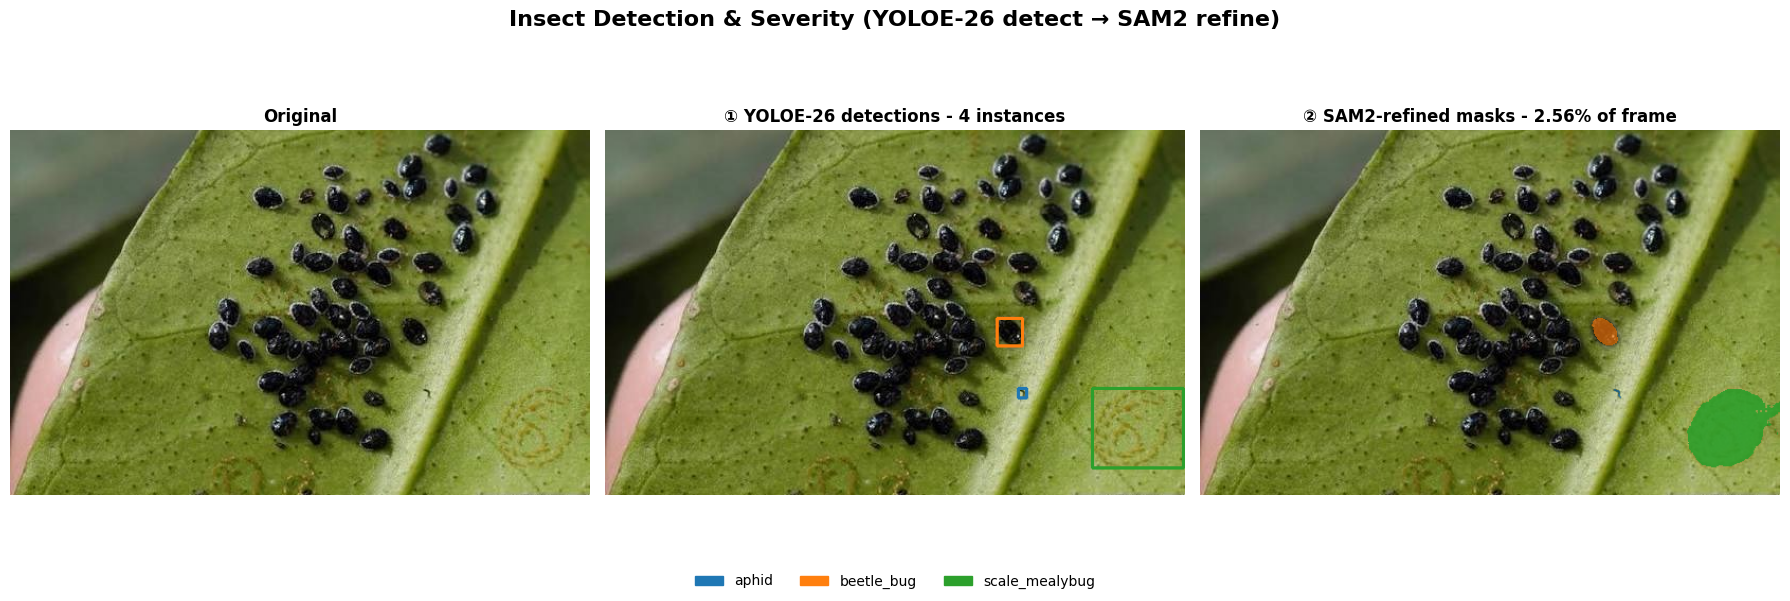

In [ ]:
def show_results(rgb, boxes, classes, masks, coverage_pct, count):
    palette = plt.cm.tab10(np.linspace(0, 1, 10))
    class_names = sorted(set(classes)) or ["none"]
    color_map = {c: palette[i % 10][:3] for i, c in enumerate(class_names)}

    boxed = rgb.copy()
    for (x1, y1, x2, y2), c in zip(boxes.astype(int) if len(boxes) else [], classes):
        color = tuple(int(v * 255) for v in color_map[c])
        cv2.rectangle(boxed, (x1, y1), (x2, y2), color, 2)

    overlay = rgb.copy()
    for m, c in zip(masks, classes):
        color = (np.array(color_map[c]) * 255).astype(np.uint8)
        overlay[m] = (0.35 * overlay[m] + 0.65 * color).astype(np.uint8)

    fig, ax = plt.subplots(1, 3, figsize=(18, 6))
    panels = [
        (rgb, "Original"),
        (boxed, f"\u2460 YOLOE-26 detections - {count} instances"),
        (overlay, f"\u2461 SAM2-refined masks - {coverage_pct:.2f}% of frame"),
    ]
    for a, (im, title) in zip(ax, panels):
        a.imshow(im)
        a.set_title(title, fontsize=12, fontweight="bold")
        a.axis("off")

    handles = [plt.Rectangle((0, 0), 1, 1, color=color_map[c]) for c in class_names]
    fig.legend(handles, class_names, loc="lower center", ncol=max(1, len(class_names)), frameon=False)
    plt.suptitle("Insect Detection & Severity (YOLOE-26 detect \u2192 SAM2 refine)", fontsize=16, fontweight="bold")
    plt.tight_layout(rect=[0, 0.06, 1, 0.95])
    plt.show()


show_results(rgb, f_boxes, f_classes, instance_masks, body_coverage_pct, total_insects)

## 2. Generate Proposals & Apply Physical Filters

We generate masks using a dense point grid, then filter by size, shape (ovality/solidity), and color (darkness relative to the leaf background).

In [ ]:
from ultralytics.models.sam import SAM2Predictor

# Dense grid for small, touching insects
overrides = dict(conf=0.25, task="segment", mode="predict", imgsz=1024, model="sam2_l.pt")
predictor = SAM2Predictor(overrides=overrides)

print("Generating automatic mask proposals...")
res_sam = predictor(source=IMG_PATH, points_stride=64, crop_n_layers=1)[0]
raw_masks = res_sam.masks.data.cpu().numpy() > 0.5
print(f"SAM2 proposed {len(raw_masks)} total masks.")

Generating automatic mask proposals (this may take a minute)...

Ultralytics 8.4.131 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
image 1/1 /content/citrus_citrusblackfly_00222 (1).jpeg: 1024x1024 1 0, 1 1, 1 2, 1 3, 1 4, 1 5, 1 6, 1 7, 1 8, 1 9, 1 10, 1 11, 1 12, 1 13, 1 14, 1 15, 1 16, 1 17, 1 18, 1 19, 1 20, 1 21, 1 22, 1 23, 1 24, 1 25, 1 26, 1 27, 1 28, 1 29, 1 30, 1 31, 1 32, 1 33, 1 34, 1 35, 1 36, 1 37, 1 38, 1 39, 1 40, 1 41, 1 42, 1 43, 1 44, 1 45, 1 46, 1 47, 1 48, 82893.6ms
Speed: 8.8ms preprocess, 82893.6ms inference, 2.8ms postprocess per image at shape (1, 3, 1024, 1024)
Results saved to /content/runs/segment/predict-3
SAM2 proposed 49 total masks.


## 12. Geometric & Color Filtering

We filter the raw masks by:
1. **Size**: Rejecting things too small (noise) or too large (leaf sections).
2. **Shape**: Rejecting long/skinny objects (veins) in favor of ovals.
3. **Color**: Ensuring the object is darker than the median leaf brightness (specifically for black scale/blackfly).

In [ ]:
lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
L_channel = lab[:, :, 0].astype(float)
img_area = H * W
median_L = np.median(L_channel)

final_masks = []
final_boxes = []

for m in raw_masks:
    area = m.sum()
    # 1. Size Filter
    if not (0.00002 * img_area < area < 0.005 * img_area):
        continue

    ys, xs = np.where(m)
    x1, y1, x2, y2 = xs.min(), ys.min(), xs.max(), ys.max()
    bw, bh = (x2 - x1) + 1, (y2 - y1) + 1

    # 2. Aspect Ratio (Reject veins)
    if max(bw, bh) / max(1, min(bw, bh)) > 2.5:
        continue

    # 3. Solidity (Reject ragged regions)
    if area / (bw * bh) < 0.50:
        continue

    # 4. Color (Must be darker than leaf)
    if L_channel[m].mean() > (median_L - 10):
        continue

    final_masks.append(m)
    final_boxes.append([x1, y1, x2, y2])

final_boxes = np.array(final_boxes) if final_boxes else np.zeros((0, 4))
final_classes = ["insect"] * len(final_masks)
print(f"Filtered down to {len(final_masks)} insects.")

Filtered down to 44 insect instances.


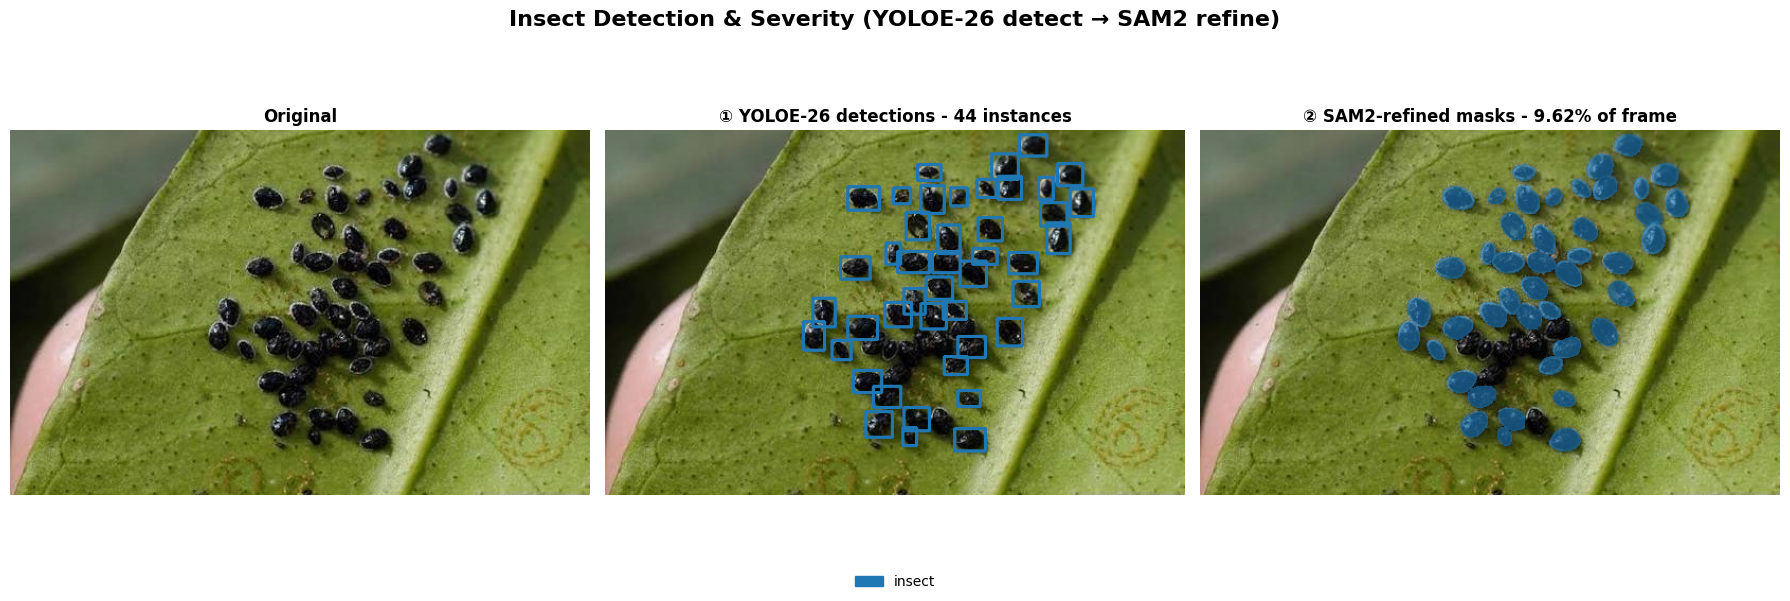

In [ ]:
# Visualize the new SAM2-driven results
if len(final_masks) > 0:
    cov_pct = 100.0 * np.logical_or.reduce(final_masks).sum() / img_area
else:
    cov_pct = 0.0

show_results(rgb, final_boxes, final_classes, final_masks, cov_pct, len(final_masks))

## Notes / tuning

- **Why 0 detections happened before**: the old leaf mask wasn't used to *find*
  insects, only to *filter* them — but a wrong (near-empty) leaf mask meant
  `inside_frac` was computed against almost no leaf pixels, so every real detection
  failed that check and got silently dropped, even if YOLOE found them. Removing the
  leaf-mask dependency removes that failure mode entirely; what's left to debug if
  you still get 0 is prompts and `conf`, both isolated to cells 3–4 now.
- **If detections are still 0** after this change: (1) widen `INSECT_PROMPTS` with
  phrases describing what's actually in the image — generic category words like
  "insect" often underperform a concrete visual description; (2) lower `conf` further
  (try 0.02–0.03); (3) switch to the visual-prompt cell (§7) and crop an exemplar by
  hand — for objects that don't match common web captions (this looks like it could be
  scale insects, beetle pupae, or egg cases — all underrepresented classes) a visual
  exemplar from your own photo is far more reliable than any text phrase.
- **`max_area_frac=0.15`** is now relative to the whole frame, not the leaf, and looser
  than before — tighten it back down once you're confident real instances aren't
  being rejected.
- **Coverage is %-of-frame, not %-of-leaf.** If you need a true leaf-relative number,
  add a leaf segmentation step back in, but make it more robust than a single center
  point — e.g. SAM2's automatic mask generator plus "pick the largest mask touching
  the image border/center," or a dedicated leaf-outline heuristic (Otsu on saturation)
  as a sanity check before trusting the point-prompt result.
- **Stippling, sooty mold, chlorosis** are intentionally not in the detector — they have
  no object boundary. Measure them as texture/color channels separately.
- **Validate before trusting the numbers**: hand-count insects on 40–60 images and track
  count MAE/MAPE and recall@IoU 0.3.
- **Next step**: use this pipeline to pre-annotate your ~550 images (correct in CVAT/
  Roboflow rather than draw from scratch), then train a small closed-set detector on a
  collapsed schema once you have real instance counts per class.

## 3. Robust Leaf Segmentation & Visualization

We segment the leaf blade to calculate infestation severity as a percentage of the leaf area.

Leaf mask source: sam2
Leaf area        : 161,109 px (85.2% of frame)
Insects on leaf  : 44 (of 44 total)
Body coverage   : 11.29% of leaf area


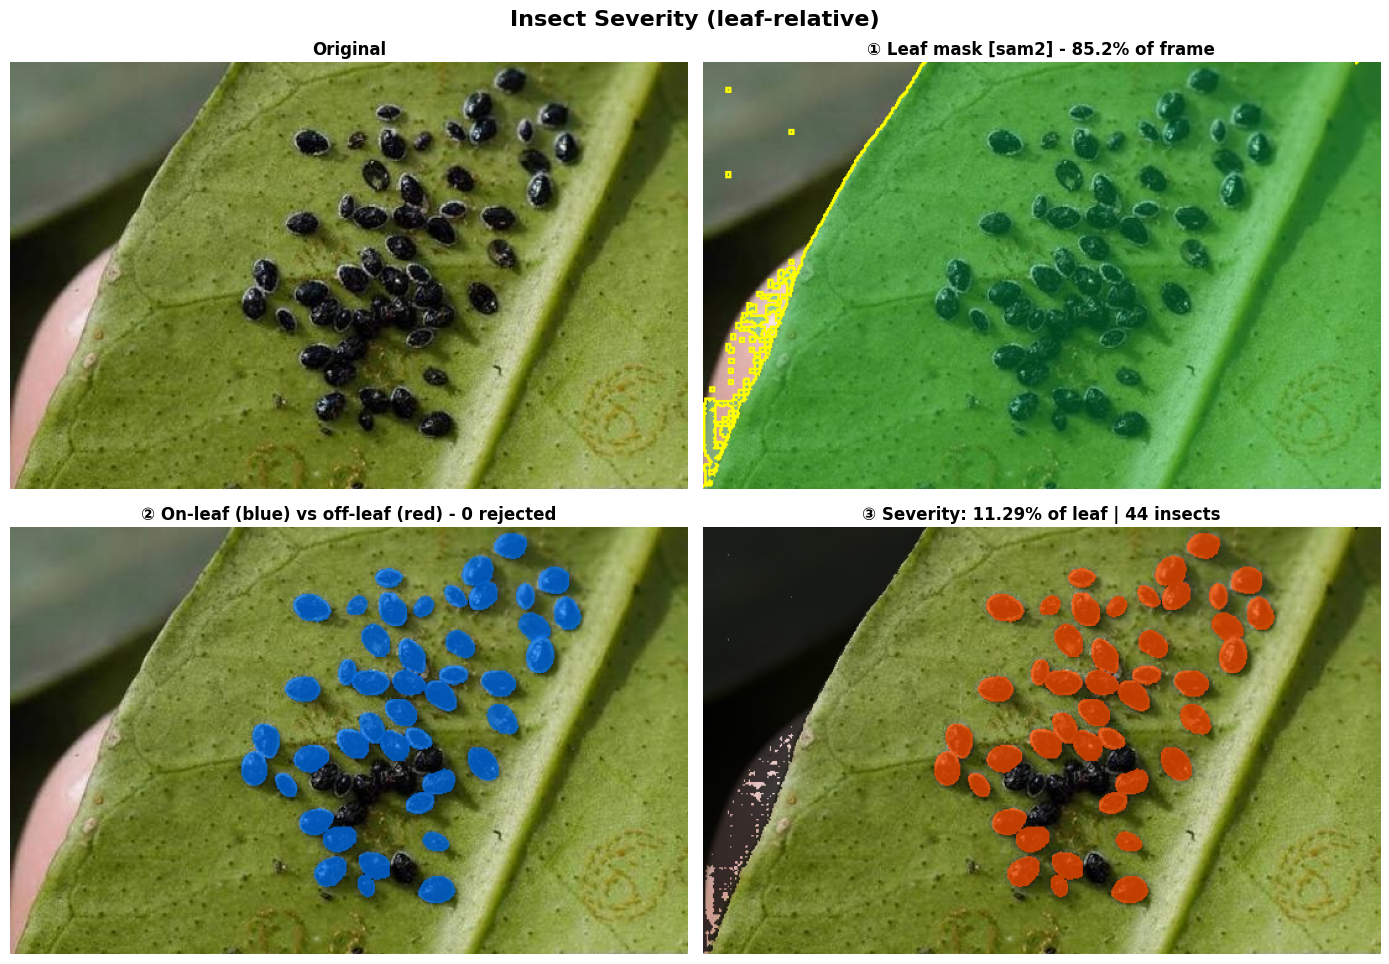

In [ ]:
def segment_leaf_robust(sam_model, bgr, rgb, insect_masks, min_frac=0.15):
    H, W = bgr.shape[:2]
    lab = cv2.cvtColor(rgb, cv2.COLOR_RGB2LAB)
    a = lab[:, :, 1].astype(float)
    green = a < np.percentile(a, 45)
    green = ndimage.binary_opening(green, np.ones((9, 9)))
    lbl, n = ndimage.label(green)
    if n:
        sizes = ndimage.sum(green, lbl, range(1, n + 1))
        green = lbl == (np.argmax(sizes) + 1)
    green = ndimage.binary_fill_holes(green)

    ys, xs = np.where(ndimage.binary_erosion(green, np.ones((25, 25))))
    if len(xs) == 0: return green, "color-only"
    idx = np.linspace(0, len(xs) - 1, 12).astype(int)
    pos = [[int(xs[i]), int(ys[i])] for i in idx]
    for m in insect_masks[:8]:
        if m.any():
            iy, ix = np.where(m)
            pos.append([int(ix.mean()), int(iy.mean())])

    neg = [[8, 8], [W - 8, 8], [8, H - 8], [W - 8, H - 8]]
    neg = [p for p in neg if not green[min(p[1], H - 1), min(p[0], W - 1)]]

    res = sam_model.predict(bgr, points=[pos + neg], labels=[[1]*len(pos) + [0]*len(neg)], verbose=False)
    if res[0].masks is None: return green, "color-fallback"
    mask = ndimage.binary_fill_holes(res[0].masks.data.cpu().numpy()[0] > 0.5)
    return (mask, "sam2") if mask.sum() > min_frac * H * W else (green, "color-sanity")

leaf_mask, leaf_source = segment_leaf_robust(sam_model, bgr, rgb, final_masks)
for m in final_masks: leaf_mask |= m

leaf_px = int(leaf_mask.sum())
body_union = np.logical_or.reduce(final_masks) if final_masks else np.zeros_like(leaf_mask)
coverage_pct = 100.0 * (body_union & leaf_mask).sum() / max(1, leaf_px)
on_leaf_count = sum(1 for m in final_masks if (m & leaf_mask).sum() > 0.5 * m.sum())

print(f"Severity: {coverage_pct:.2f}% coverage | {on_leaf_count} insects on leaf")

# Visualization function call
show_leaf_results(rgb, leaf_mask, final_masks, final_classes, leaf_source, leaf_px, on_leaf_count, coverage_pct)